# AG-HYPOPT · Trial 01

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Campaign start for experiment_4: tune the FROZEN inversion pipeline on the REAL measured FWHM data (8-experiment subset: 1 nW & 3 nW x Trans05/20/60/100), using the real FWHM distribution as target. `trials.json` is empty, so there are no previous trials and no current best to anchor on; cell 2 is therefore in the uniform warm-up phase (0/5 completed) and every candidate is an independent random draw. Context only.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_01'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 20    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = uniform  (0/5 trials)
ID |     ei | params
 1 |      - | {"gamma_anneal": 0.38386621852519254, "lr_gamma": 0.9603709570607484, "lr_mu": 8.603990317990844, "sigma_ref": 23.972988942744877}
 2 |      - | {"gamma_anneal": 0.2338735890078641, "lr_gamma": 0.5386611591780606, "lr_mu": 25.692564845511043, "sigma_ref": 13.183982727383226}
 3 |      - | {"gamma_anneal": 0.4121952657547946, "lr_gamma": 0.22204729059445472, "lr_mu": 23.837827716870166, "sigma_ref": 15.762866264385565}
 4 |      - | {"gamma_anneal": 0.24729878737431912, "lr_gamma": 0.8307429627427234, "lr_mu": 12.579870732291123, "sigma_ref": 14.06995778961303}
 5 |      - | {"gamma_anneal": 0.10053127293537356, "lr_gamma": 0.5224903891577034, "lr_mu": 10.08638101690374, "sigma_ref": 10.24626680883699}
 6 |      - | {"gamma_anneal": 0.5627735044725395, "lr_gamma": 0.424327006388832, "lr_mu": 17.129774360790876, "sigma_ref": 24.61474399602477}
 7 |      - | {"gamma_anneal": 0.72124289524784, "lr_gamma": 0.7798319526188269, 

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

No previous trials are recorded (`trials.json` empty) and the proposer is still in the uniform warm-up phase, so there is no evidence yet to exploit and no exploiter/interpreter mode to act on: the candidates are independent uniform draws over (sigma_ref, lr_mu, lr_gamma, gamma_anneal) with no ranking information. With nothing to prefer, the first enumerated proposal is as good as any. I choose candidate 1.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 1               # first candidate (uniform phase, no evidence yet)


chosen: {'gamma_anneal': 0.38386621852519254, 'lr_gamma': 0.9603709570607484, 'lr_mu': 8.603990317990844, 'sigma_ref': 23.972988942744877}
Running  1nW Trans05 ... 

μ 9.39 -> 4.71 | γ 8.5 -> 3.63 | NLL 1.29


Running  1nW Trans20 ... 

μ 17.32 -> 8.67 | γ 8.5 -> 4.15 | NLL 3.04


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 51.03 | γ 14.1 -> 13.95 | NLL 3.17


Running 3nW Trans100 ... 

μ 175.71 -> 86.76 | γ 14.1 -> 14.01 | NLL 2.77



Total: 2.4 min


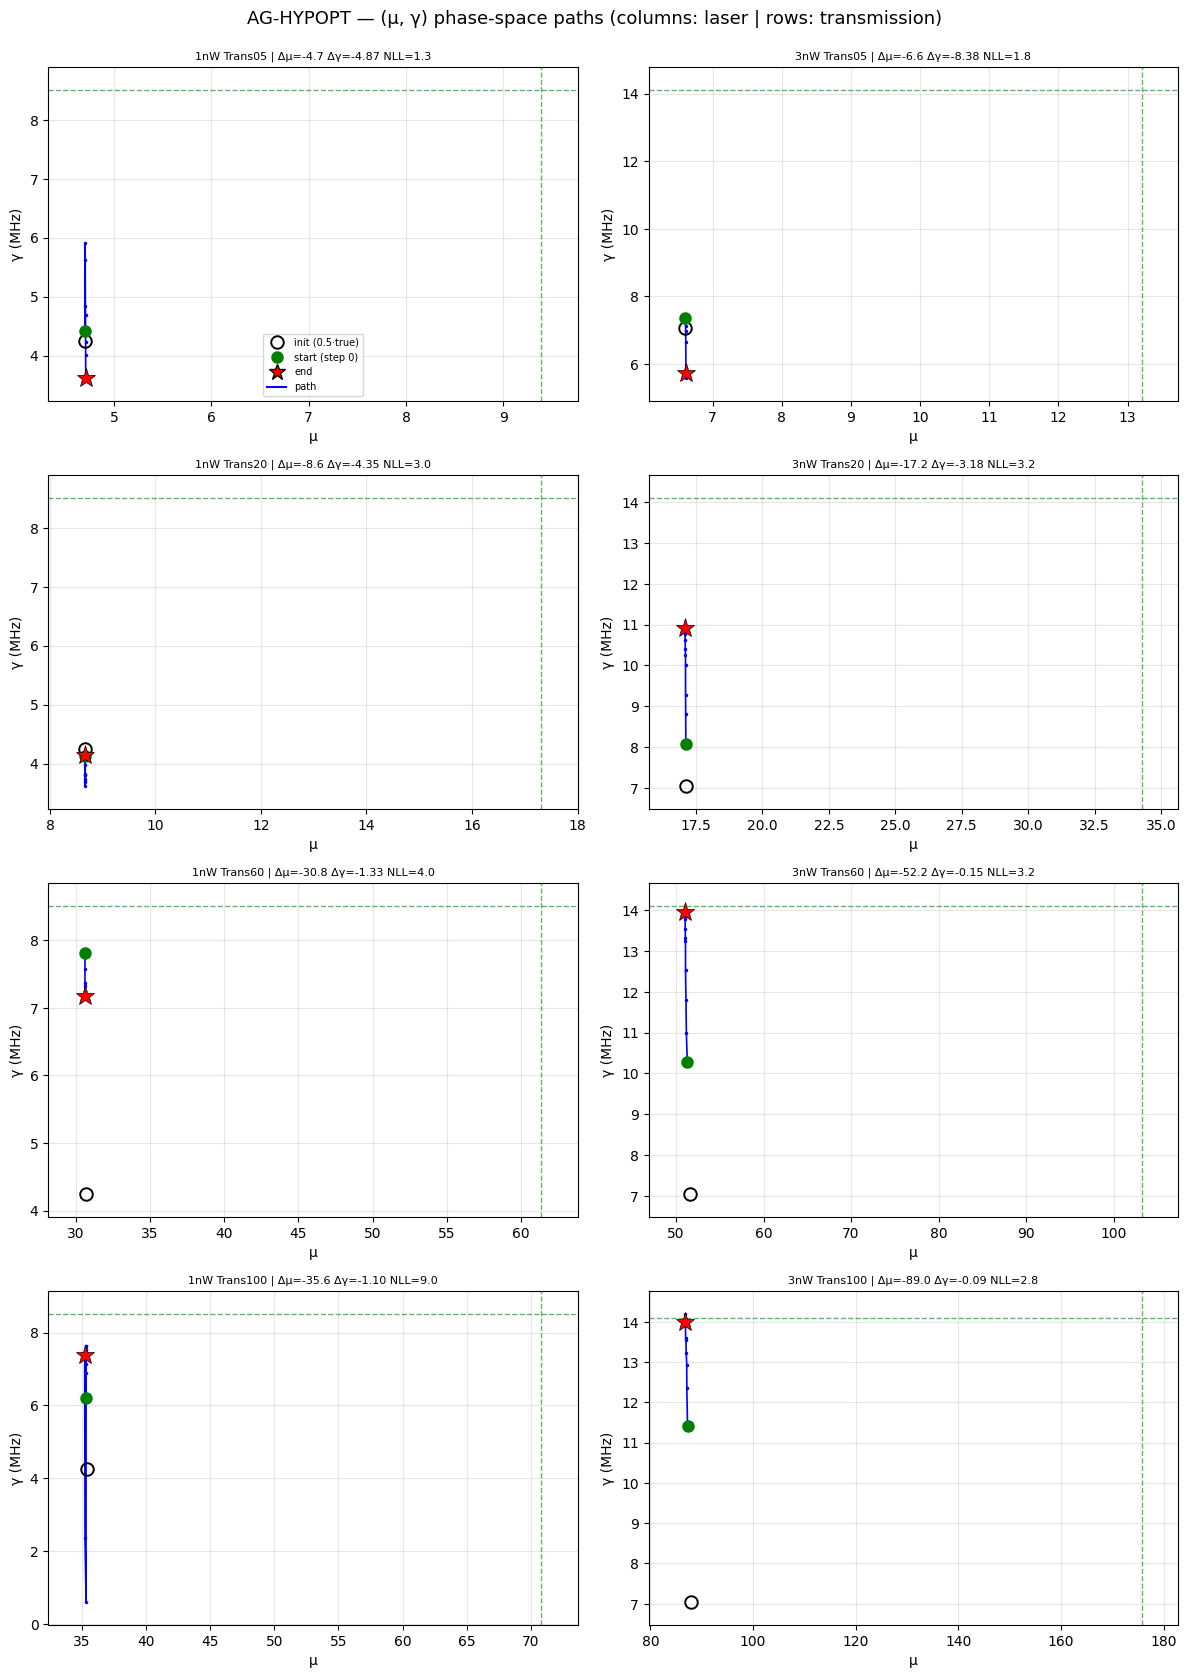

trial finished in 2.4 min
objective = 0.1907 ± 0.0310
exp           μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05     9.39    4.71   -49.9 |     8.50    3.63   -57.4
1nW Trans20    17.32    8.67   -49.9 |     8.50    4.15   -51.2
1nW Trans60    61.37   30.60   -50.1 |     8.50    7.17   -15.6
1nW Trans100   70.82   35.22   -50.3 |     8.50    7.40   -13.0
3nW Trans05    13.20    6.62   -49.9 |    14.10    5.72   -59.4
3nW Trans20    34.28   17.09   -50.1 |    14.10   10.92   -22.6
3nW Trans60   103.20   51.03   -50.6 |    14.10   13.95    -1.1
3nW Trans100  175.71   86.76   -50.6 |    14.10   14.01    -0.7

μ: RMSE 40.749 (rel 50.2%, bias -30.575) | γ: RMSE 3.969 (rel 36.0%, bias -2.932)


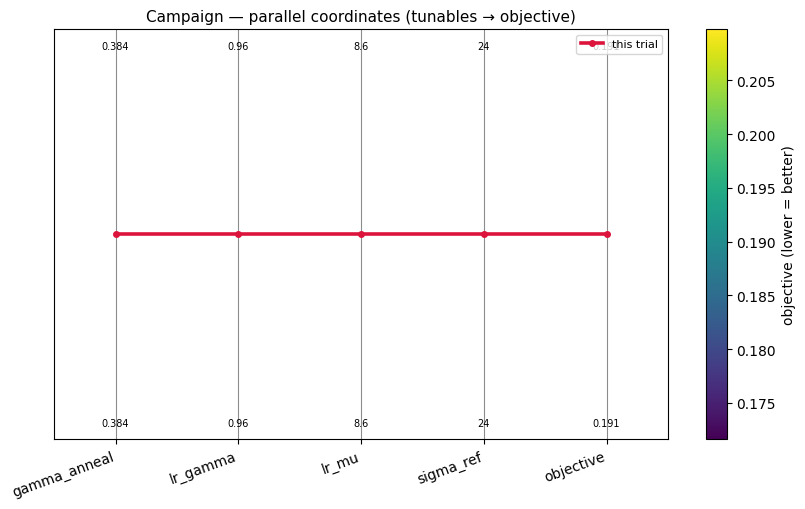

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 01, first trial; the proposer ran in the uniform warm-up phase (0/5), so the config is an uninformative random draw: sigma_ref 23.97, lr_mu 8.60, lr_gamma 0.960, gamma_anneal 0.384. Result: objective 0.1907 +/- 0.0310, runtime 2.4 min. The per-experiment table shows mu_fit at almost exactly half of mu_true in every one of the 8 experiments (Delta-mu% between -49.9 and -50.6), giving mu RMSE 40.75 (relative 50.2%, bias -30.6) -- the clean 'attractor at half-truth' signature. gamma_fit is heterogeneous: near-truth at high transmission (3 nW Trans60/100: -1.1%/-0.7%; 1 nW Trans60/100: -15.6%/-13.0%) but collapsed at low transmission (Trans05: -57.4% at 1 nW, -59.4% at 3 nW); gamma RMSE 3.97 (relative 36.0%, bias -2.9). There are no previous trials to compare against.

**Summary:** Trial 01 (sigma_ref 23.97, lr_mu 8.60, lr_gamma 0.960, gamma_anneal 0.384) -> objective 0.1907 +/- 0.0310; mu recovers at a clean ~50% of truth on all 8 experiments and gamma collapses only at low transmission.
**Key insight:** The real-data attractor floor (~half of mu_true) reappears uniformly across all 8 experiments regardless of these hyperparameters and dominates the objective, while gamma is recovered well only at high transmission.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
Notes for Anuar (structural, not acted on): the uniform -50% mu offset on every experiment is the 18b real-data attractor (context 7.7) -- a likelihood/model-data mismatch rather than an optimizer artifact -- so the likely fix is structural (e.g. a pseudo-Voigt simulator, context 7.6) and probably not reachable by tuning the four hyperparameters alone.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 01 (sigma_ref 23.97, lr_mu 8.60, lr_gamma 0.960, gamma_anneal 0.384): objective 0.1907 +/- 0.0310; mu recovers at a clean ~50% of truth on all 8 experiments, gamma only at high transmission'
KEY_INSIGHT = 'The real-data attractor floor (~half of mu_true) is uniform across all 8 experiments and dominates the objective, while gamma is recovered well only at high transmission.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_01 | current best: trial_01


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_02.ipynb. Open it and follow its cells from the top.
